In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df= pd.read_csv('../datasets/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# fill age with median


df['Age']=df['Age'].fillna( df['Age'].median() )

In [9]:
#doped cabin column with null because it has more than 70% null 

df=df.drop(columns=['Cabin'])

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: ylabel='Frequency'>

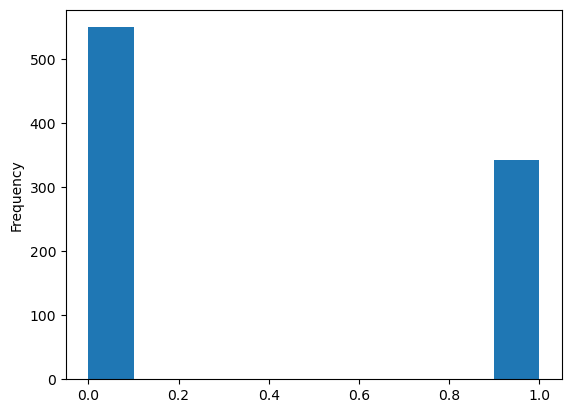

In [11]:
df['Survived'].plot( kind='hist' )

<Axes: ylabel='count'>

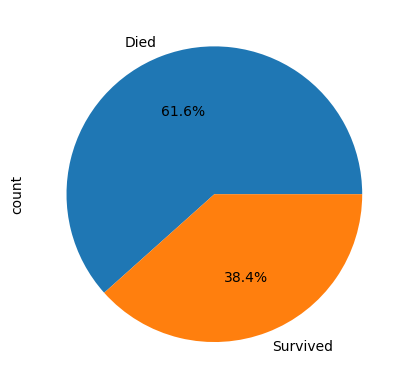

In [12]:
df['Survived'].value_counts().plot(kind='pie', autopct='%1.1f%%',labels=['Died','Survived'])

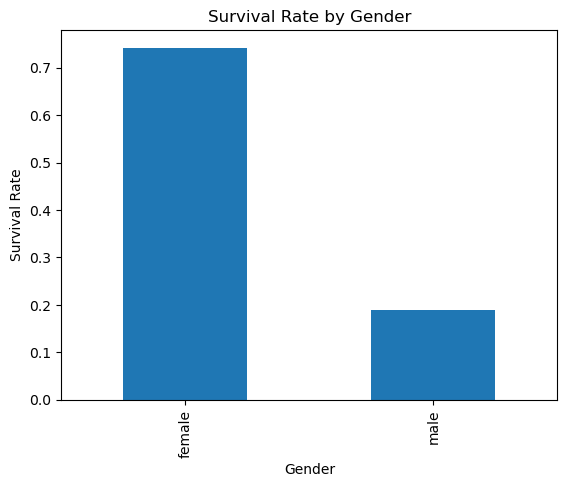

In [13]:

df.groupby('Sex')['Survived'].mean().plot(kind='bar')

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xlabel("Gender")

plt.show()

<Axes: xlabel='Sex'>

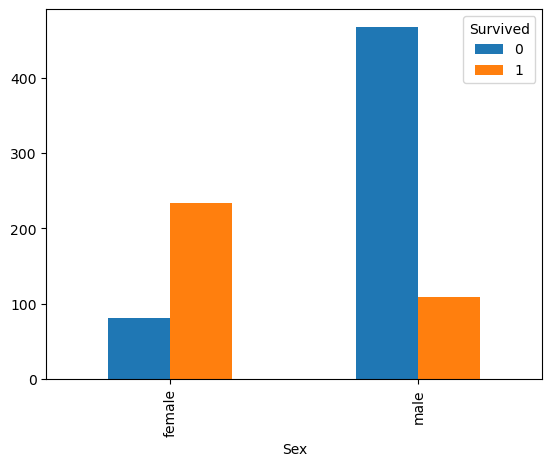

In [14]:
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')

<Axes: xlabel='Pclass'>

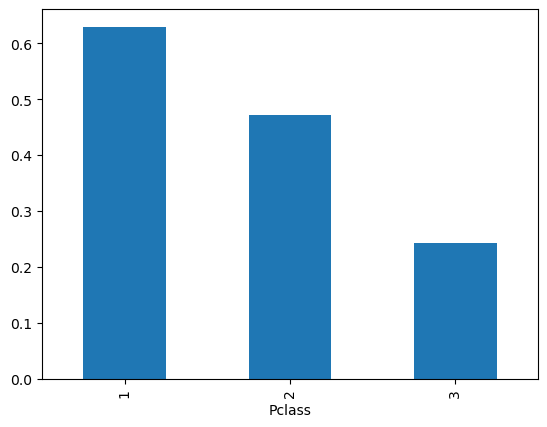

In [15]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

<Axes: xlabel='Pclass'>

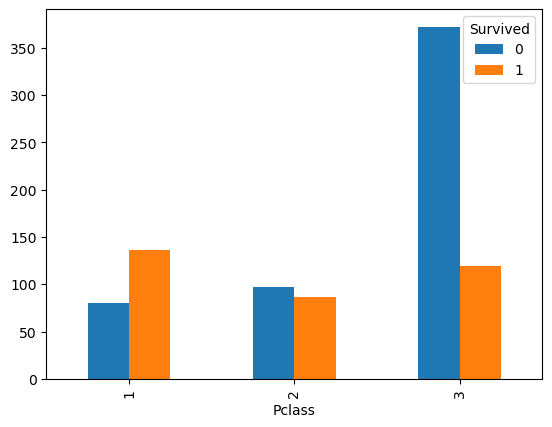

In [16]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')

In [17]:
df['Age'].mean()

np.float64(29.36158249158249)

In [18]:
df['Age'].min()

0.42

In [19]:
df['Age'].max()

80.0

<Axes: ylabel='Frequency'>

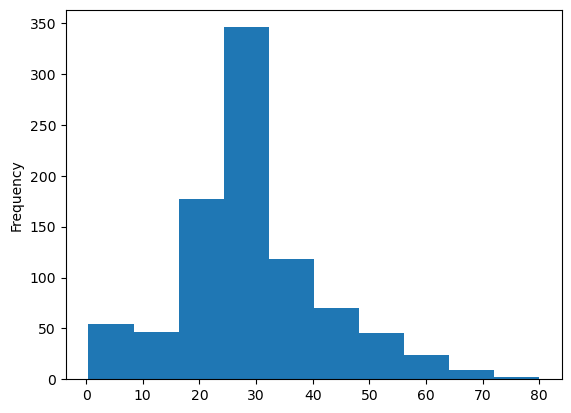

In [20]:
df['Age'].plot(kind='hist')

<Axes: xlabel='Survived'>

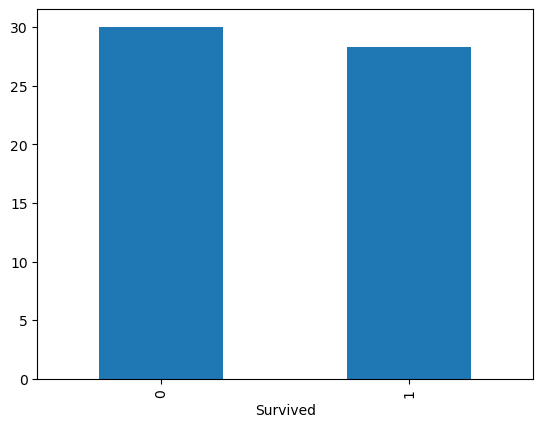

In [21]:
df.groupby('Survived')['Age'].mean().plot(kind='bar')

In [22]:
df['Fare'].mean()

np.float64(32.204207968574636)

In [23]:
df['Fare'].min()

0.0

In [24]:
df['Fare'].max()

512.3292

<Axes: xlabel='Fare'>

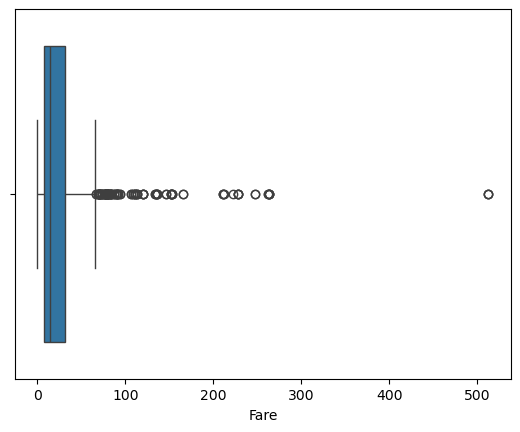

In [25]:
sns.boxplot(x=df['Fare'])

<Axes: xlabel='Fare', ylabel='Count'>

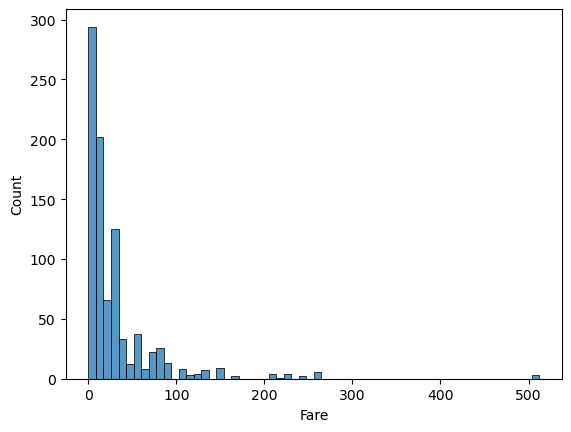

In [26]:
sns.histplot(x=df['Fare'])

<Axes: xlabel='Survived', ylabel='Fare'>

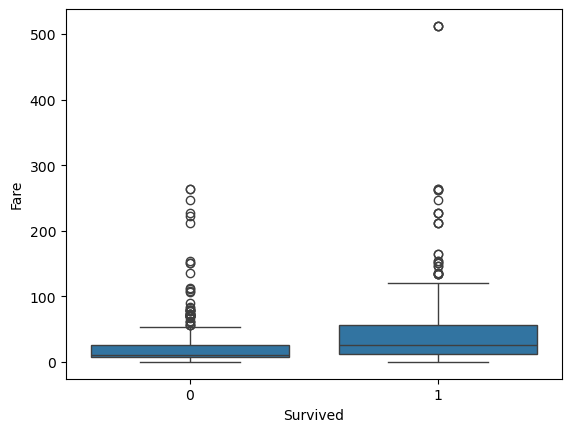

In [27]:
sns.boxplot(x='Survived', y='Fare', data=df)

In [28]:
df['FareGroup'] = pd.cut(df['Fare'], bins=[0,10,30,100,600],
                         labels=['Low','Medium','High','Very High'])

C:\Users\user\AppData\Local\Temp\ipykernel_29308\3644323688.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('FareGroup')['Survived'].mean().plot(kind='bar')


<Axes: xlabel='FareGroup'>

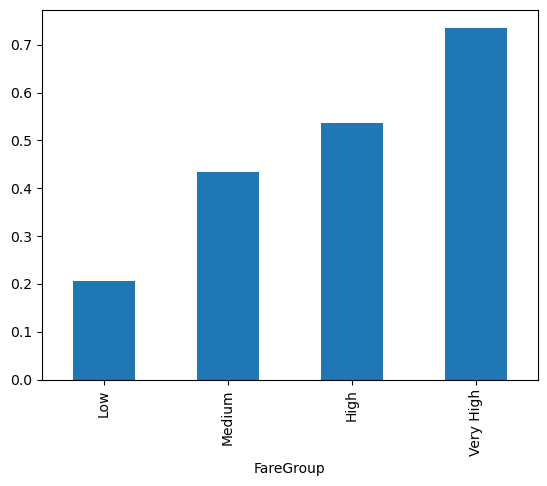

In [29]:
df.groupby('FareGroup')['Survived'].mean().plot(kind='bar')

<Axes: xlabel='Embarked'>

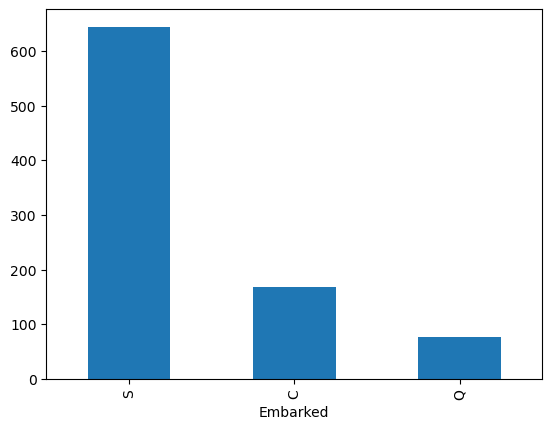

In [30]:
df['Embarked'].value_counts().plot(kind='bar')

<Axes: xlabel='Survived,Embarked'>

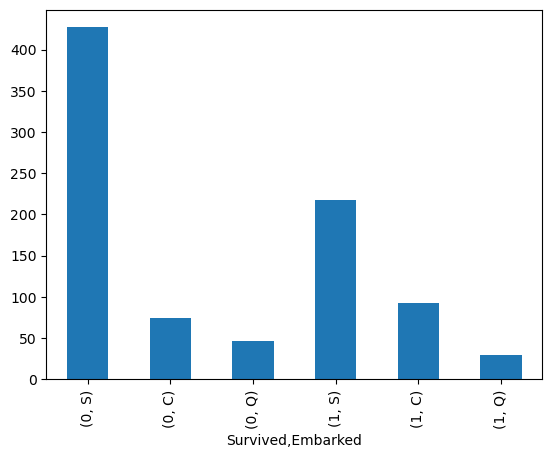

In [34]:
df.groupby('Survived')['Embarked'].value_counts().plot(kind='bar')

In [38]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [39]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FareGroup,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Low,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,High,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Low,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,High,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Low,1


<Axes: xlabel='FamilySize'>

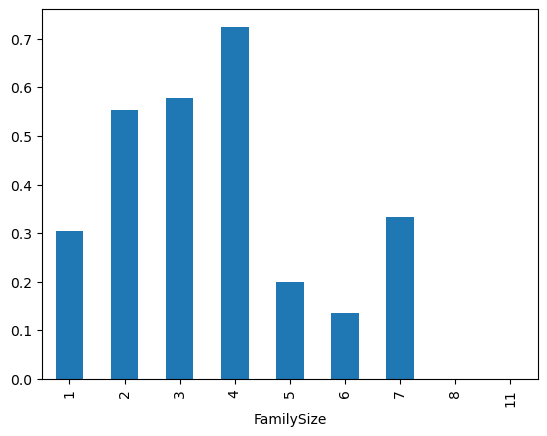

In [40]:
df.groupby('FamilySize')['Survived'].mean().plot(kind='bar')